# Practical Statistics for Data Scientists - Chapter 3
## Statistical Experiments and Significance Testing

This notebook covers A/B testing concepts, permutation tests, p-values, t-tests, ANOVA (Analysis of Variance), Chi-Square tests, and statistical power/sample size estimation using Python.

### Environment Setup and Imports

In [6]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## 1. A/B Testing & Permutation Tests

A permutation test (randomization test) combines responses from multiple treatment groups, reshuffles them into synthetic groups under the null hypothesis ($H_0$), and measures how often a difference as extreme as the observed difference occurs by chance.

### Data Loading

Loads web page session time data.

In [7]:
session_times = pd.read_csv('drive/MyDrive/Colab Notebooks/data/web_page_data.csv')

### Observed Difference Calculation

Calculates the observed difference in mean session time between Page A and Page B.

In [8]:
mean_a = session_times[session_times['Page'] == 'Page A']['Time'].mean()
mean_b = session_times[session_times['Page'] == 'Page B']['Time'].mean()
obs_diff = mean_b - mean_a
print(f"Observed Mean Difference (Page B - Page A): {obs_diff:.2f} seconds")

Observed Mean Difference (Page B - Page A): 0.36 seconds


### Permutation Function

Defines a helper function for the permutation test.

In [9]:
def perm_fun(x, n1, n2):
    n = n1 + n2
    idx_b = set(random.sample(range(n), n1))
    idx_a = set(range(n)) - idx_b
    return x.iloc[list(idx_b)].mean() - x.iloc[list(idx_a)].mean()

### Running Permutations

Runs 1,000 permutations to generate a distribution of differences.

In [10]:
n_a = session_times[session_times['Page'] == 'Page A'].shape[0]
n_b = session_times[session_times['Page'] == 'Page B'].shape[0]

random.seed(42)
perm_diffs = [perm_fun(session_times['Time'], n_a, n_b) for _ in range(1000)]

### Computing p-value

Computes the empirical p-value from the permutation distribution.

In [11]:
p_value = np.mean([diff >= obs_diff for diff in perm_diffs])
print(f"Permutation Test Empirical p-value: {p_value:.4f}")

Permutation Test Empirical p-value: 0.1200


### Plotting Permutation Distribution

Visualizes the permutation distribution and the observed difference.

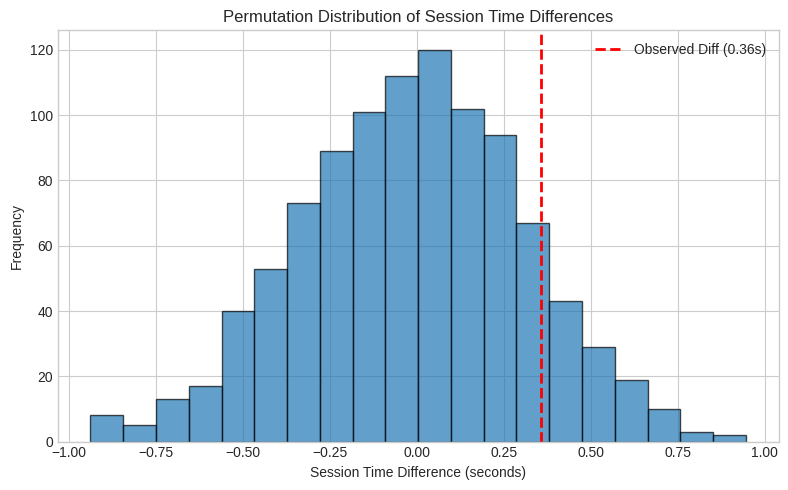

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(perm_diffs, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=obs_diff, color='red', lw=2, linestyle='--', label=f'Observed Diff ({obs_diff:.2f}s)')
ax.set_xlabel('Session Time Difference (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Permutation Distribution of Session Time Differences')
ax.legend()
plt.tight_layout()
plt.show()

---

## 2. Statistical Significance and t-Tests

Comparing two independent group means using **Welch's Two-Sample t-Test** ($t$-statistic and theoretical $p$-value).

### Performing Welch's t-test

Performs Welch's Two-Sample t-test, assuming unequal variances, to compare session times between Page A and Page B.

In [13]:
time_a = session_times[session_times['Page'] == 'Page A']['Time']
time_b = session_times[session_times['Page'] == 'Page B']['Time']

t_stat, p_val = stats.ttest_ind(time_b, time_a, equal_var=False)

print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"Two-tailed p-value:  {p_val:.4f}")

if p_val < 0.05:
    print("Verdict: Statistically significant difference at alpha = 0.05.")
else:
    print("Verdict: Fail to reject the null hypothesis (no significant difference).")

Welch's t-statistic: 1.0983
Two-tailed p-value:  0.2815
Verdict: Fail to reject the null hypothesis (no significant difference).


---

## 3. ANOVA (Analysis of Variance)

Comparing numeric responses across **3 or more groups** simultaneously using the $F$-statistic to evaluate variation between groups versus variation within groups.

### Loading ANOVA Data

Loads data for a multi-page test with four different pages.

In [14]:
four_sessions = pd.read_csv('drive/MyDrive/Colab Notebooks/data/four_sessions.csv')

### One-way ANOVA with SciPy

Performs a one-way ANOVA using SciPy's `f_oneway` function to compare means across four groups.

In [15]:
f_stat, p_val_anova = stats.f_oneway(
    four_sessions[four_sessions['Page'] == 'Page 1']['Time'],
    four_sessions[four_sessions['Page'] == 'Page 2']['Time'],
    four_sessions[four_sessions['Page'] == 'Page 3']['Time'],
    four_sessions[four_sessions['Page'] == 'Page 4']['Time']
)

print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"ANOVA p-value:     {p_val_anova:.4f}")

ANOVA F-Statistic: 2.7398
ANOVA p-value:     0.0776


### Detailed ANOVA Table with Statsmodels

Generates a detailed ANOVA table using Statsmodels Ordinary Least Squares (OLS) regression.

In [16]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA Table:")
print(anova_table)


ANOVA Table:
          sum_sq    df         F    PR(>F)
Page       831.4   3.0  2.739825  0.077586
Residual  1618.4  16.0       NaN       NaN


---

## 4. Chi-Square Test of Independence

Evaluating relationships between **categorical variables** (e.g., ad creative variants vs. conversion outcomes).

### Constructing Contingency Table

Constructs a contingency table comparing 3 headline options against click/no-click outcomes.

In [17]:
clicks = pd.DataFrame(
    [
        [14, 986],   # Headline A: 14 Clicks, 986 No-Clicks
        [8, 992],    # Headline B: 8 Clicks, 992 No-Clicks
        [12, 988]    # Headline C: 12 Clicks, 988 No-Clicks
    ],
    columns=['Click', 'No-Click'],
    index=['Headline A', 'Headline B', 'Headline C']
)

print("Observed Contingency Table:")
print(clicks)

Observed Contingency Table:
            Click  No-Click
Headline A     14       986
Headline B      8       992
Headline C     12       988


### Performing Chi-Square Test

Executes the Chi-Square test of independence to determine if there's a significant association between headlines and clicks.

In [18]:
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(clicks)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom:   {dof}")
print(f"p-value:              {p_val_chi2:.4f}")


Chi-Square Statistic: 1.6659
Degrees of Freedom:   2
p-value:              0.4348


---

## 5. Statistical Power and Sample Size Estimation

Determining the required sample size ($n$) to detect a target effect size given a significance level ($\alpha$) and power ($1 - \beta$).

### Calculating Required Sample Size

Calculates the required sample size per group for a two-sided t-test, given a specified effect size, alpha, and target power.

In [20]:
effect_size = 0.20  # Small effect size (Cohen's d)
alpha = 0.05       # Significance threshold
power = 0.80       # Target power (80% chance to detect effect)

power_analysis = TTestIndPower()
req_sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative='two-sided'
)

print(f"Required Sample Size per group (for d={effect_size}, power={power}): {math.ceil(req_sample_size):,}")

Required Sample Size per group (for d=0.2, power=0.8): 394
